In [5]:
import tensorflow as tf
import numpy as np
import os
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, BatchNormalization, ReLU, Input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from sklearn.model_selection import train_test_split

In [6]:
# Define paths
base_path = r"Derain dataset\Dataset"  
train_input_path = os.path.join(base_path, "train/input")
train_target_path = os.path.join(base_path, "train/target")
val_input_path = os.path.join(base_path, "validation/input")  
val_target_path = os.path.join(base_path, "validation/target")
test_input_path = os.path.join(base_path, "test/input")
test_target_path = os.path.join(base_path, "test/target")

IMG_SIZE = (256, 256)

# Function to load images
def load_images(image_path, target_path):
    images, targets = [], []
    for img_name in os.listdir(image_path):
        img = img_to_array(load_img(os.path.join(image_path, img_name), target_size=IMG_SIZE)) / 255.0
        tgt = img_to_array(load_img(os.path.join(target_path, img_name), target_size=IMG_SIZE)) / 255.0
        images.append(img)
        targets.append(tgt)
    return np.array(images), np.array(targets)

# Load datasets
X_train, y_train = load_images(train_input_path, train_target_path)
X_val, y_val = load_images(val_input_path, val_target_path) 
X_test, y_test = load_images(test_input_path, test_target_path)

In [6]:
# Building CNN

def build_model():
    inputs = Input(shape=(256, 256, 3))

    # Conv Block 1
    x = Conv2D(64, (3,3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Conv Block 2
    x = Conv2D(128, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Conv Block 3
    x = Conv2D(256, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Refinement Block 1
    x = Conv2D(128, (3,3), padding='same', strides=1)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Refinement Block 2
    x = Conv2D(64, (3,3), padding='same', strides=1)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Output Layer
    outputs = Conv2D(3, (3,3), padding='same', activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model

# Define PSNR function
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

# Define SSIM function
def ssim_metric(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

# Create model
model = build_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=[psnr_metric, ssim_metric])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 256, 256, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256, 256, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 256, 256, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 256, 256, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 743,939 (2.84 MB)

 Trainable params: 742,659 (2.83 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
# # Load and Resume Training (For 40 More Epochs)

# from tensorflow.keras.models import load_model
# from tensorflow.keras.callbacks import EarlyStopping

# # Load the saved model
# model = load_model("de_rain_model.h5", custom_objects={"psnr_metric": psnr_metric, "ssim_metric": ssim_metric})

# # Define EarlyStopping callback
# early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Continue training for 40 more epochs
# history2 = model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=40,  
#     batch_size=16,
#     callbacks=[early_stopping]  # Include Early Stopping
# )

# # Save final trained model
# model.save("de_rain_model_final.h5")
# print("Final model saved as de_rain_model_final.h5")

In [10]:
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, LeakyReLU, Add, UpSampling2D
from tensorflow.keras.models import Model

def build_derain_model():
    inputs = Input(shape=(256, 256, 3))

    # Encoder
    c1 = Conv2D(64, (3, 3), strides=1, padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = LeakyReLU(alpha=0.1)(c1)

    c2 = Conv2D(128, (3, 3), strides=2, padding='same')(c1)
    c2 = BatchNormalization()(c2)
    c2 = LeakyReLU(alpha=0.1)(c2)

    c3 = Conv2D(256, (3, 3), strides=2, padding='same')(c2)
    c3 = BatchNormalization()(c3)
    c3 = LeakyReLU(alpha=0.1)(c3)

    # Bottleneck
    b = Conv2D(512, (3, 3), padding='same')(c3)
    b = BatchNormalization()(b)
    b = LeakyReLU(alpha=0.1)(b)

    # Decoder
    u1 = UpSampling2D()(b)
    u1 = Conv2D(256, (3, 3), padding='same')(u1)
    u1 = BatchNormalization()(u1)
    u1 = LeakyReLU(alpha=0.1)(u1)
    c3_upsampled = UpSampling2D(size=(2, 2))(c3)  # Fixed
    u1 = Add()([u1, c3_upsampled])

    u2 = UpSampling2D()(u1)
    u2 = Conv2D(128, (3, 3), padding='same')(u2)
    u2 = BatchNormalization()(u2)
    u2 = LeakyReLU(alpha=0.1)(u2)
    c2_upsampled = UpSampling2D(size=(2, 2))(c2)  # Fixed
    u2 = Add()([u2, c2_upsampled])

    u3 = Conv2D(64, (3, 3), padding='same')(u2)
    u3 = BatchNormalization()(u3)
    u3 = LeakyReLU(alpha=0.1)(u3)
    u3 = Add()([u3, c1])

    outputs = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(u3)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Define PSNR function
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

# Define SSIM function
def ssim_metric(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

# Compile model
model = build_derain_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="mse",
              metrics=[psnr_metric, ssim_metric])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_19      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │     73,856 │ leaky_re_lu_19[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_20      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │    295,168 │ leaky_re_lu_20[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_21      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │  1,180,160 │ leaky_re_lu_21[0… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      2,048 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_22      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_9     │ (None, 128, 128,  │          0 │ leaky_re_lu_22[0… │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 128, 128,  │  1,179,904 │ up_sampling2d_9[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_23      │ (None, 128, 128,  │          0 │ batch_normalizat

 Total params: 3,107,075 (11.85 MB)

 Trainable params: 3,104,259 (11.84 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,  
    batch_size=8,
    callbacks=[early_stopping]  # Adding Early Stopping
)

# model.save("de_rain_model.h5")
# print("Final model saved as de_rain_model.h5")

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 2099s 24s/step - loss: 0.0107 - psnr_metric: 20.3876 - ssim_metric: 0.6438 - val_loss: 0.0668 - val_psnr_metric: 11.9553 - val_ssim_metric: 0.3324
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1486s 17s/step - loss: 0.0074 - psnr_metric: 22.1052 - ssim_metric: 0.7396 - val_loss: 0.0535 - val_psnr_metric: 12.9382 - val_ssim_metric: 0.4082
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1103s 13s/step - loss: 0.0059 - psnr_metric: 22.9672 - ssim_metric: 0.7506 - val_loss: 0.0377 - val_psnr_metric: 14.4713 - val_ssim_metric: 0.4893
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1039s 12s/step - loss: 0.0061 - psnr_metric: 22.9773 - ssim_metric: 0.7656 - val_loss: 0.0293 - val_psnr_metric: 15.5425 - val_ssim_metric: 0.5564
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1033s 12s/step - loss: 0.0058 - psnr_metric: 22.9705 - ssim_metric: 0.7632 - val_loss: 0.0186 - val_psnr_metric: 17.4559 - val_ssim_metric: 0.6443
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1029s 12s/step - loss: 0.0058 - psnr_

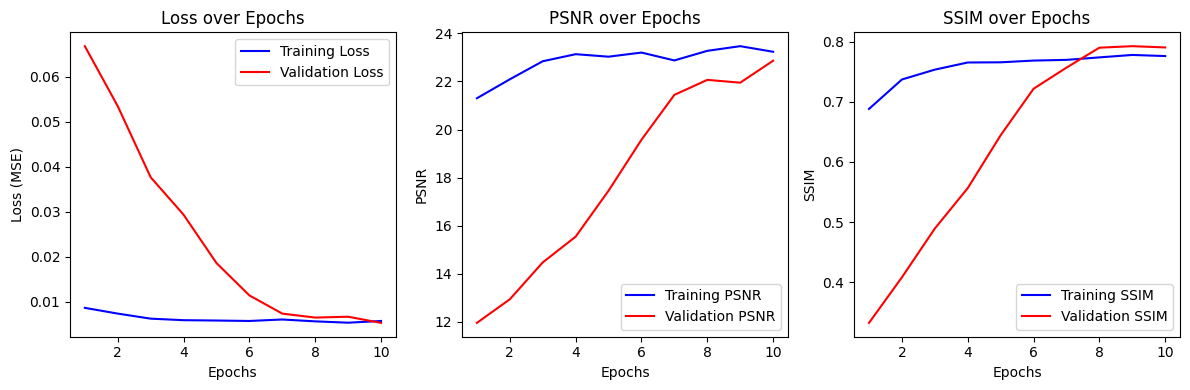

In [16]:
import matplotlib.pyplot as plt

# Extract history data
loss = history.history['loss']
val_loss = history.history['val_loss']
psnr = history.history['psnr_metric']
val_psnr = history.history['val_psnr_metric']
ssim = history.history['ssim_metric']
val_ssim = history.history['val_ssim_metric']

epochs = range(1, len(loss) + 1)

# Plot Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

# Plot PSNR
plt.subplot(1, 3, 2)
plt.plot(epochs, psnr, 'b-', label='Training PSNR')
plt.plot(epochs, val_psnr, 'r-', label='Validation PSNR')
plt.title('PSNR over Epochs')
plt.xlabel('Epochs')
plt.ylabel('PSNR')
plt.legend()

# Plot SSIM
plt.subplot(1, 3, 3)
plt.plot(epochs, ssim, 'b-', label='Training SSIM')
plt.plot(epochs, val_ssim, 'r-', label='Validation SSIM')
plt.title('SSIM over Epochs')
plt.xlabel('Epochs')
plt.ylabel('SSIM')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# Evaluate Model with PSNR, SSIM, MSE

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    psnr_values, ssim_values, mse_values = [], [], []

    for i in range(len(X_test)):
        pred = predictions[i]
        target = y_test[i]

        # Compute PSNR, SSIM, and MSE
        psnr_value = psnr(target, pred, data_range=1.0)
        ssim_value = ssim(target, pred, channel_axis=-1, data_range=1.0, win_size=11)  
        mse_value = np.mean((target - pred) ** 2)

        psnr_values.append(psnr_value)
        ssim_values.append(ssim_value)
        mse_values.append(mse_value)

    print(f"Average PSNR: {np.mean(psnr_values):.2f}")
    print(f"Average SSIM: {np.mean(ssim_values):.4f}")
    print(f"Average MSE: {np.mean(mse_values):.6f}")

# Evaluate the model
evaluate_model(model, X_test, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 201s 20s/step
Average PSNR: 21.27
Average SSIM: 0.7368
Average MSE: 0.008940


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step


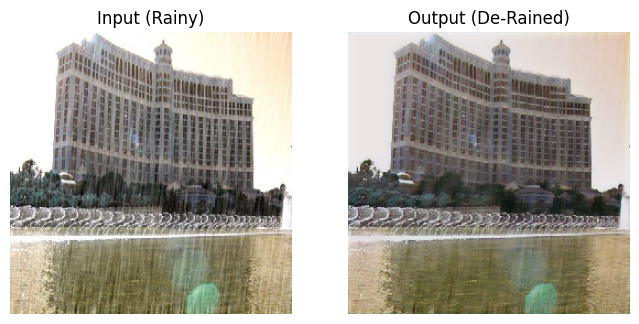

In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (256, 256) 

def de_rain_image(model, image_path):
    # Load input image
    img = img_to_array(load_img(image_path, target_size=IMG_SIZE)) / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict output
    pred = model.predict(img)[0]
    pred = np.clip(pred, 0, 1)  # Ensure pixel values are valid

    # Convert back to uint8 image
    input_img = (img[0] * 255).astype(np.uint8)
    output_img = (pred * 255).astype(np.uint8)

    return input_img, output_img

# Test on a sample image
test_image_path = r"Derain dataset\3.png"
input_image, output_image = de_rain_image(model, test_image_path)

# Display input and output side by side
plt.figure(figsize=(8, 5))

# Input Image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))
plt.title("Input (Rainy)")
plt.axis("off")

# Output Image
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title("Output (De-Rained)")
plt.axis("off")

plt.show()